# PORTER DELIVERY DATA ANALYSIS 

In [1]:
import pandas as pd
import numpy as num
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


### Basic Information About Dataset

In [4]:
print('Number of Rows:',df.shape[0])
print('Number of columns:',df.shape[1])

Number of Rows: 197428
Number of columns: 14


In [5]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

In [7]:
df.describe()

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


### Understanding the dataset

In [8]:
for col in df.columns:
    print(col)

market_id
created_at
actual_delivery_time
store_id
store_primary_category
order_protocol
total_items
subtotal
num_distinct_items
min_item_price
max_item_price
total_onshift_partners
total_busy_partners
total_outstanding_orders


### Checking missing values

In [9]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_df.sort_values(by='Missing Percentage', ascending=False)

    
    

,Missing Values,Missing Percentage
total_onshift_partners,16262,8.236927
total_busy_partners,16262,8.236927
total_outstanding_orders,16262,8.236927
store_primary_category,4760,2.411006
order_protocol,995,0.503981
market_id,987,0.499929
actual_delivery_time,7,0.003546
created_at,0,0.000000
store_id,0,0.000000
total_items,0,0.000000


In [10]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Values,Missing Percentage
total_onshift_partners,16262,8.236927
total_busy_partners,16262,8.236927
total_outstanding_orders,16262,8.236927
store_primary_category,4760,2.411006
order_protocol,995,0.503981
market_id,987,0.499929
actual_delivery_time,7,0.003546
created_at,0,0.000000
store_id,0,0.000000
total_items,0,0.000000


In [11]:
print('Duplicate Rows:',df.duplicated().sum())

Duplicate Rows: 0


### Convert data columns

In [12]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df[['created_at','actual_delivery_time']].head()

,created_at,actual_delivery_time
0,2015-02-06 22:24:17,2015-02-06 23:27:16
1,2015-02-10 21:49:25,2015-02-10 22:56:29
2,2015-01-22 20:39:28,2015-01-22 21:09:09
3,2015-02-03 21:21:45,2015-02-03 22:13:00
4,2015-02-15 02:40:36,2015-02-15 03:20:26


### Create delivery time feature

In [13]:
df['delivery_time_minutes'] = (
    (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60
)
df[['created_at','actual_delivery_time','delivery_time_minutes']].head()

,created_at,actual_delivery_time,delivery_time_minutes
0,2015-02-06 22:24:17,2015-02-06 23:27:16,62.983333
1,2015-02-10 21:49:25,2015-02-10 22:56:29,67.066667
2,2015-01-22 20:39:28,2015-01-22 21:09:09,29.683333
3,2015-02-03 21:21:45,2015-02-03 22:13:00,51.250000
4,2015-02-15 02:40:36,2015-02-15 03:20:26,39.833333


#### Data Analysis

In [14]:
market_orders = df.groupby('market_id').size().sort_values(ascending=False)

market_orders
    

market_id
2.0    55058
4.0    47599
1.0    38037
3.0    23297
5.0    18000
6.0    14450
dtype: int64

### Visualization

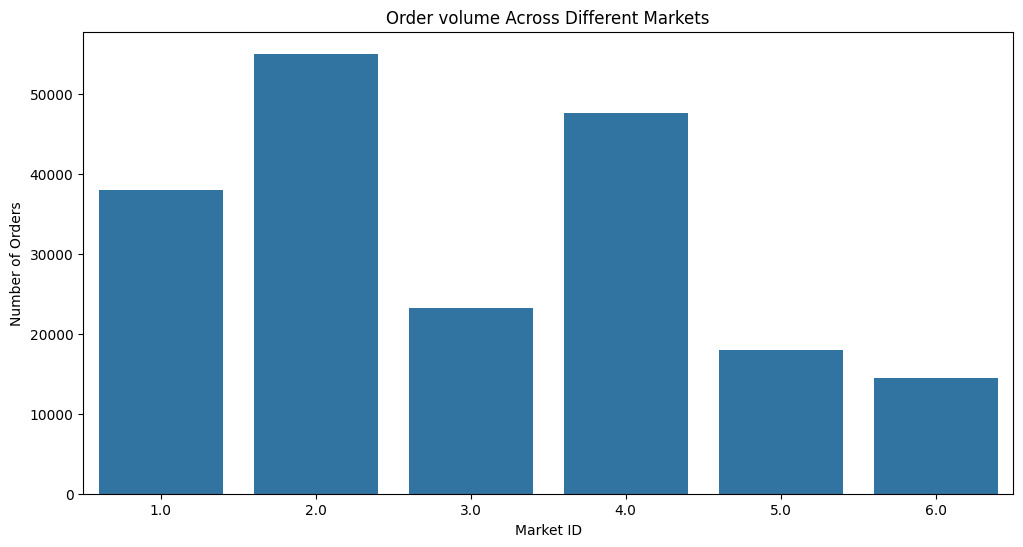

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=market_orders.index,
    y=market_orders.values
)

plt.title('Order volume Across Different Markets')
plt.xlabel('Market ID')
plt.ylabel('Number of Orders')

plt.show()

##### Porter should prioritize resource allocation and delivery operations in high-demand markets like Market 2 and Market 4 to maintain delivery efficiency and customer satisfaction.

### Percentage Distribution

In [16]:
market_percentage = (
    df['market_id']
    .value_counts(normalize=True) * 100
).round(2)

market_percentage

market_id
2.0    28.03
4.0    24.23
1.0    19.36
3.0    11.86
5.0     9.16
6.0     7.36
Name: proportion, dtype: float64

### 2.How does the average delivery time aross different store primary categories?

In [17]:
avg_delivery_category = df.groupby(
    'store_primary_category'
)['delivery_time_minutes'].mean().sort_values(ascending=False)

avg_delivery_category.head(10)

store_primary_category
italian      70.200889
spanish      56.178378
caribbean    56.098287
brazilian    55.972957
belgian      54.991667
tapas        54.250571
cajun        52.500897
malaysian    52.290196
japanese     52.077584
afghan       51.663165
Name: delivery_time_minutes, dtype: float64

### Visualization

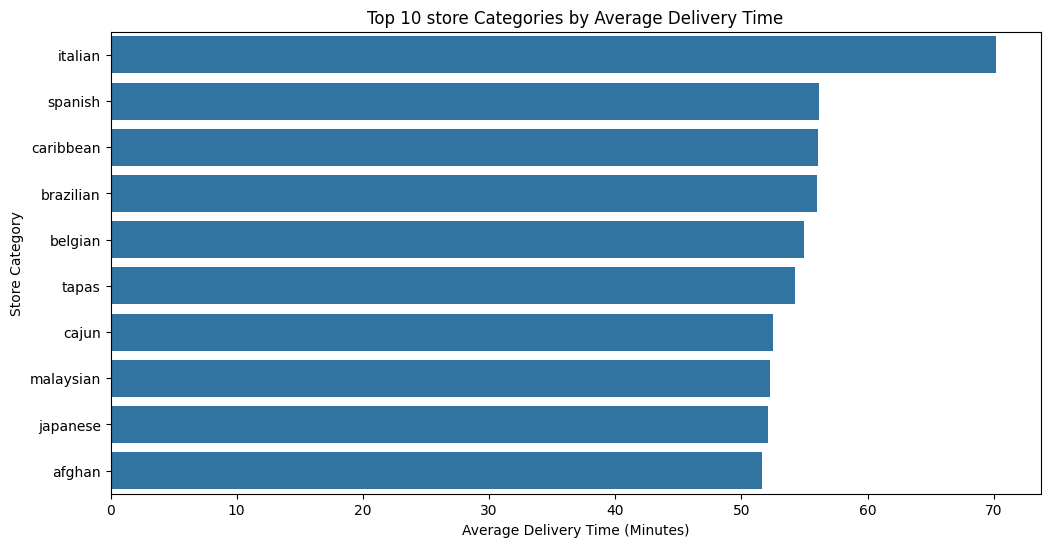

In [18]:
top_categories = avg_delivery_category.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
   x=top_categories.values,
   y=top_categories.index
)
plt.title('Top 10 store Categories by Average Delivery Time')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Store Category')

plt.show()

##### Store categories with higher delivery times may face opertional or preparation delays.

### opertional Advanced Analysis

In [19]:
category_analysis = df.groupby(
    'store_primary_category'
).agg({
    'delivery_time_minutes':'mean',
    'store_id': 'count'
}).rename(columns={
    'delivery_time_minutes': 'avg_delivery_time',
    'store_id': 'total_orders'
})

category_analysis.sort_values(
    by='avg_delivery_time',
    ascending=False
).head(10)

,avg_delivery_time,total_orders
store_primary_category,,
italian,70.200889,7179
spanish,56.178378,37
caribbean,56.098287,253
brazilian,55.972957,310
belgian,54.991667,2
tapas,54.250571,146
cajun,52.500897,316
malaysian,52.290196,102
japanese,52.077584,9196


### 3.What are the peak hours for order placements?

##### Extract Hour from Ordr Time

In [20]:
df['order_hour'] = df['created_at'].dt.hour

##### Count Orders by Hour

In [21]:
hourly_orders = df.groupby('order_hour').size()

hourly_orders

order_hour
0     12669
1     28190
2     36976
3     27068
4     15250
5      7096
6      1416
7        11
8         2
14       40
15      538
16     2109
17     3413
18     5100
19    13541
20    15560
21    11465
22     8821
23     8163
dtype: int64

##### Visualization

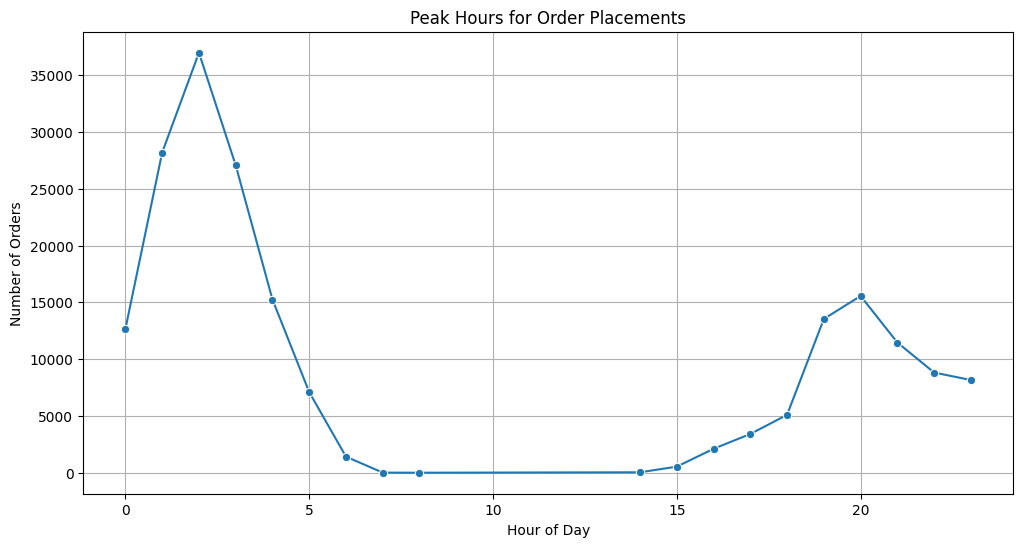

In [22]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values,
    marker='o'
)
plt.title('Peak Hours for Order Placements')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')

plt.grid(True)
plt.show()

#### 4. Which days of the week see the highest order volumes?

##### Extract Day of the Week

In [23]:
df['order_weekday'] = df['created_at'].dt.day_name()

##### Count Orders by Weekday

In [24]:
weekday_orders = df['order_weekday'].value_counts()

##### Reorder Days Properly

In [25]:
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
weekday_orders = df['order_weekday'].value_counts().reindex(days_order)
weekday_orders

order_weekday
Monday       27403
Tuesday      24062
Wednesday    24254
Thursday     25673
Friday       27875
Saturday     34541
Sunday       33620
Name: count, dtype: int64

##### Visualization

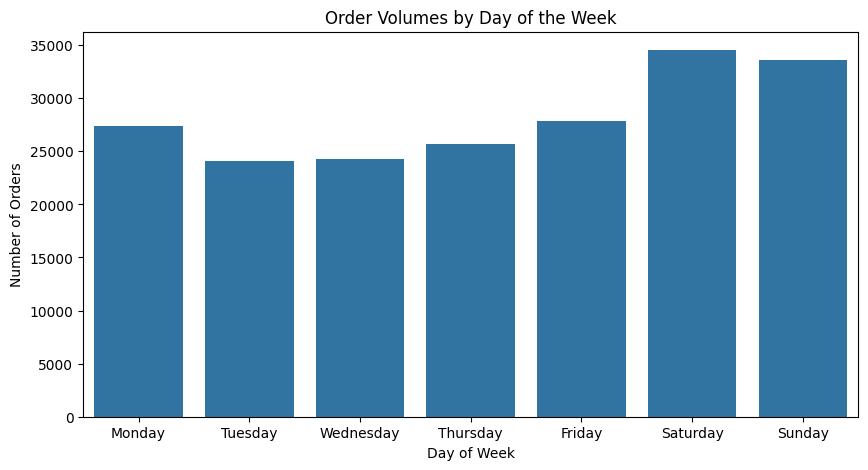

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=weekday_orders.index,
    y=weekday_orders.values
)
plt.title('Order Volumes by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

#### 5. What is the correlation between the number of items in an order and the subtotal?

##### Calculate Correlation

In [27]:
correlation = df['total_items'].corr(df['subtotal'])
print('Correlation between Total Items and subtotal:')
print(correlation)

Correlation between Total Items and subtotal:
0.5580666290539369


##### Visualization

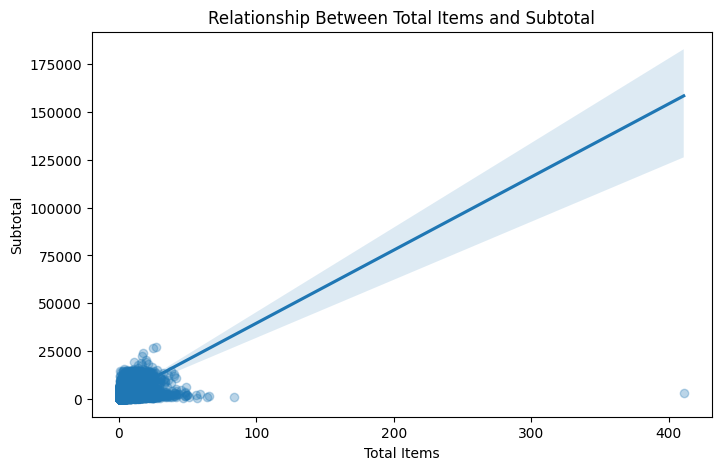

In [28]:
plt.figure(figsize=(8,5))
sns.regplot(
    x='total_items',
    y='subtotal',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title('Relationship Between Total Items and Subtotal')
plt.xlabel('Total Items')
plt.ylabel('Subtotal')
plt.show()

#### Analyze the distribution of the delivery times.Are there notable outliers?

#### Calulate Delivery Time

In [29]:
df['delivery_time_minutes'].describe()

count    197421.000000
mean         48.470956
std         320.493482
min           1.683333
25%          35.066667
50%          44.333333
75%          56.350000
max      141947.650000
Name: delivery_time_minutes, dtype: float64

#### Statistial Summary

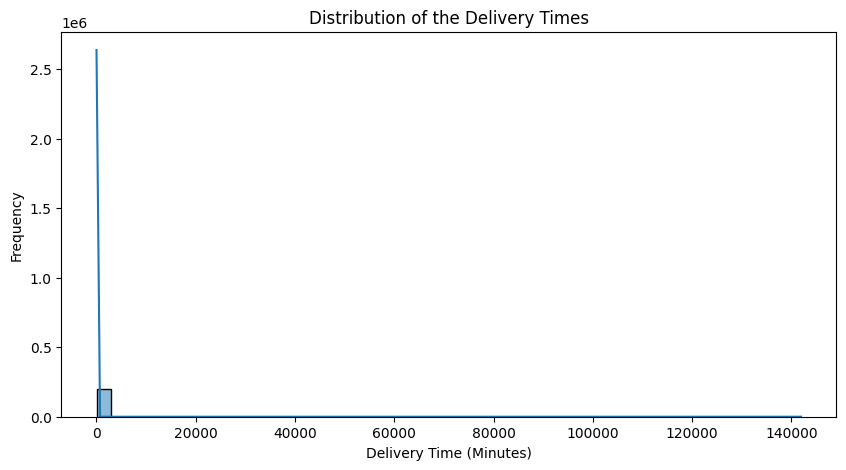

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['delivery_time_minutes'],
    bins=50,
    kde=True
)
plt.title('Distribution of the Delivery Times')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Frequency')
plt.show()

#### Distribution Plot

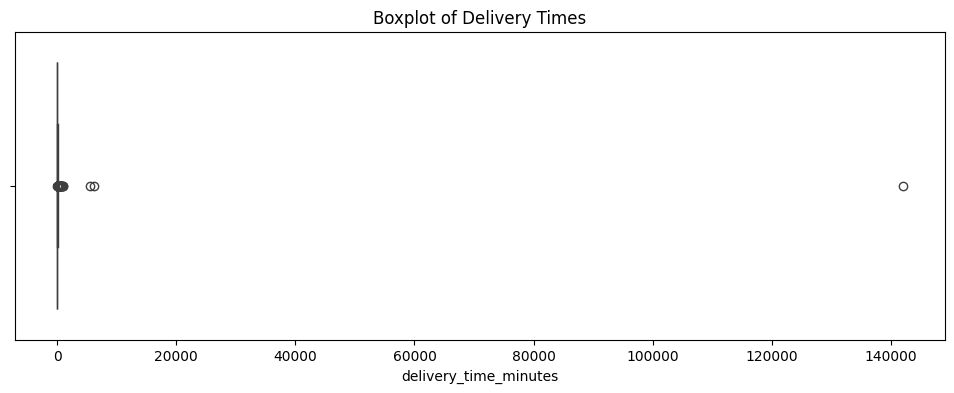

In [40]:
plt.figure(figsize=(12,4))
sns.boxplot(
    x=df['delivery_time_minutes']
)
plt.title('Boxplot of Delivery Times')
plt.show()

#### Identify Outliers Using IQR Method

In [38]:
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df[
    (df['delivery_time_minutes'] < lower_limit) |
    (df['delivery_time_minutes'] > upper_limit) 
]
print('Number of Outliers:',len(outliers))

Number of Outliers: 6278
